In [1]:
library(tidyverse)
library(glue)

Warning message:
“package ‘tibble’ was built under R version 4.2.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
# Run mmseqs for every reference against the complete references
system("mkdir -p data-preparation/mmseqs-results")
system("mkdir -p data-preparation/tmp")
# Uncomment to run mmseqs2 searches
consensus_files <- list.files("data-preparation/consensus", pattern = "\\.fasta$", full.names = TRUE)

colnames_mmseqs <- c("query,target,fident,alnlen,mismatch,gapopen,qstart,qend,qlen,tstart,tend,tlen,evalue,bits")

walk(consensus_files, function(fasta) {
  basename <- str_remove(basename(fasta), "\\.fasta$")
  potential_references <- "data-preparation/ncbi-virus-fasta/sequences_20251024_LASV.fasta"
  message(glue("Running mmseqs2 for {basename}\n"))
  system(glue("conda run -n mmseqs2-env mmseqs easy-search --max-seq-id 1.0 --search-type 3 --format-output {colnames_mmseqs} {fasta} {potential_references} data-preparation/mmseqs-results/{basename}_mmseqs.out.m8 data-preparation/tmp"))
})

Running mmseqs2 for LASV_L

Running mmseqs2 for LASV_S



In [16]:
# Combine mmseqs results
mmseqs <- list.files("data-preparation/mmseqs-results/") %>%
    map_dfr(~ {
        df <- read.table(paste0("data-preparation/mmseqs-results/", .), sep="\t", col.names = str_split(colnames_mmseqs, ",")[[1]])
        df$segment <- .
        df
    }) %>%
    mutate(segment = gsub(".*_(S|L|M)_.*", "\\1", segment))%>%
    mutate(query = gsub("_[L|S]","", query ))%>%
    filter((tlen >=6700 & tlen <=7500) | (tlen >=2900 & tlen <=3600))

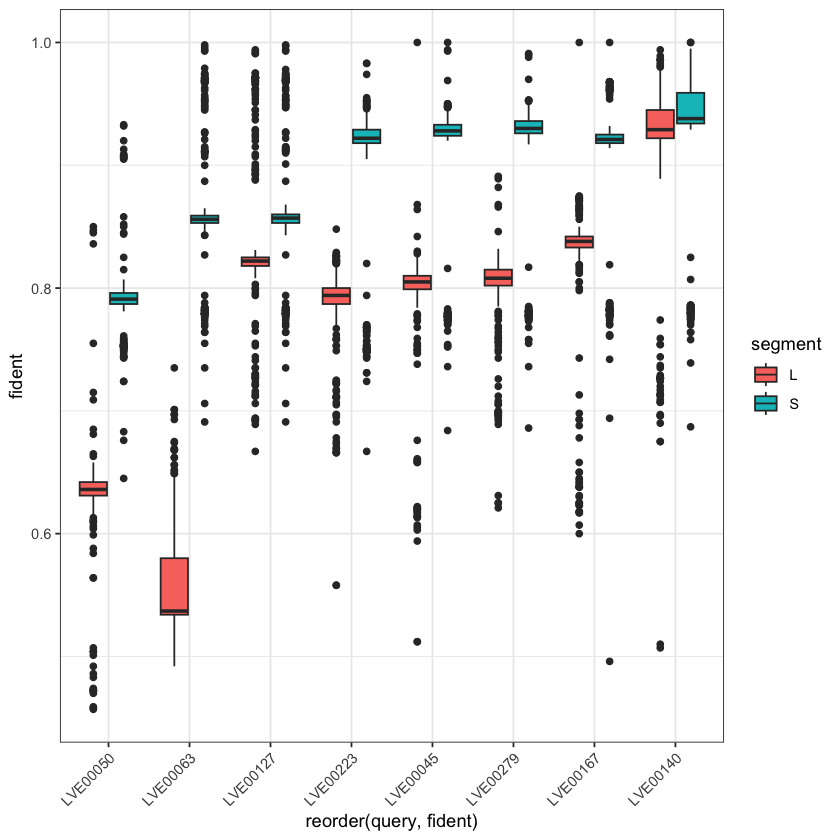

In [17]:
# Checking the observed diversity of references. (arrange with increasing mean fident)
ggplot(mmseqs, aes(y = fident, x = reorder(query, fident), fill=segment)) +
  geom_boxplot() +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [18]:
set.seed(42)
# Selecting a reference for each query in a window of [[80,82],[82,84],...,[98,100]]
selected_references <- mmseqs %>%
  filter(fident >=0.64) %>%
  filter((tlen >=6700 & tlen <=7500) | (tlen >=2900 & tlen <=3600))%>%
  mutate(fident_window = cut(fident, breaks = seq(0.64, 1, by = 0.02), include.lowest = TRUE)) %>%
  group_by(query, fident_window) %>%
  arrange(desc(alnlen)) %>%
  slice(1)

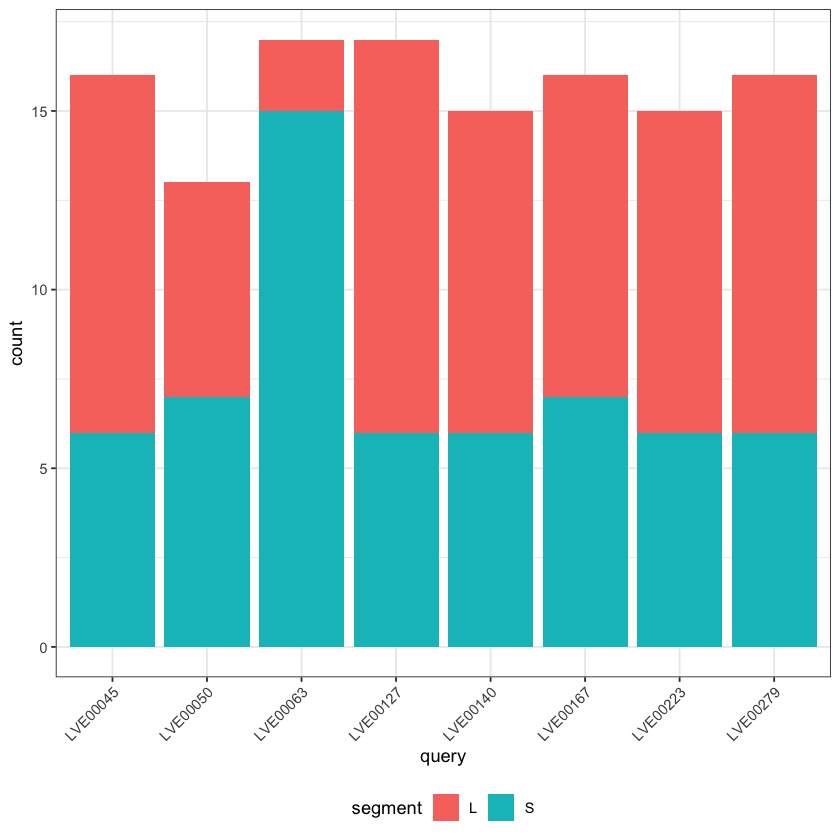

In [19]:
# Checking how many we have for every query
ggplot(selected_references, aes(x = query, fill = segment)) +
  geom_bar() +
  theme_bw() +
  theme(legend.position = "bottom") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

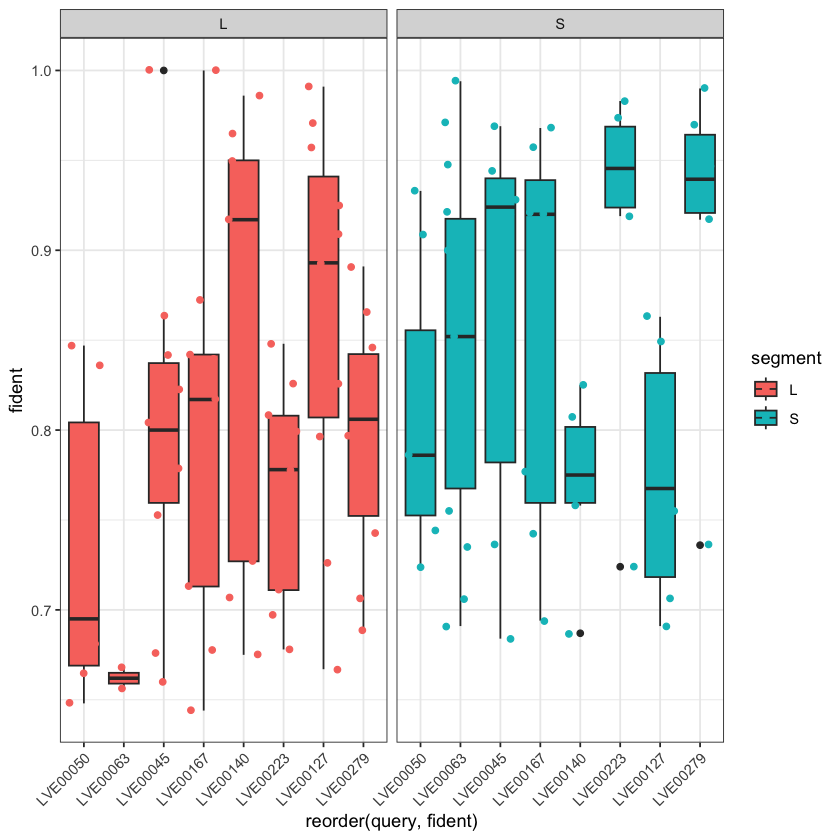

In [20]:
# Checking the observed diversity of references. (arrange with increasing mean fident)
ggplot(selected_references, aes(y = fident, x = reorder(query, fident))) +
  geom_boxplot(aes(fill=segment)) +
  geom_jitter(aes(color=segment)) +
  facet_wrap(~segment) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

The coverage on L for LVE00063 is just very bad.
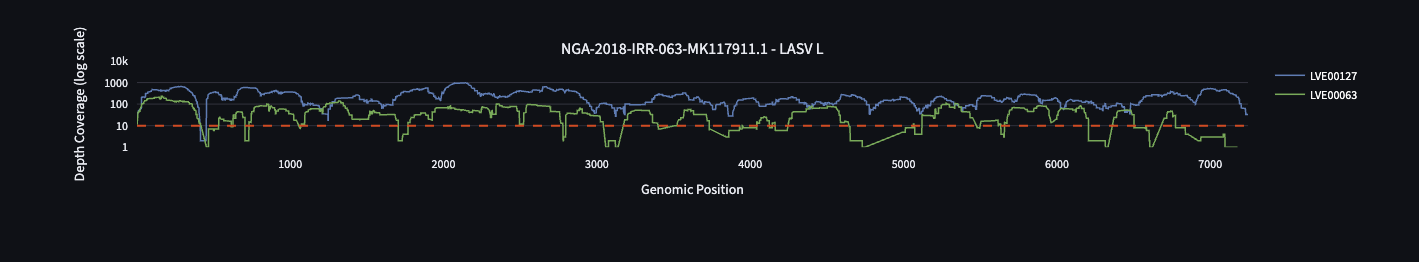


Not going to worry too much about it, I'm just going to start by selecting one sample (LVE00050) and one reference per window of identity.


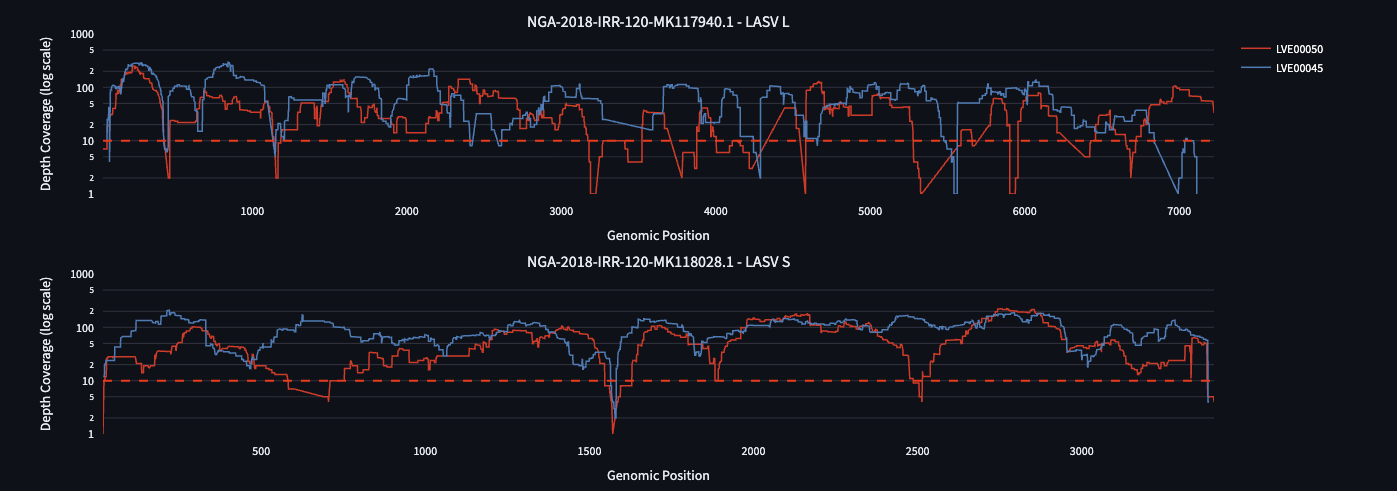


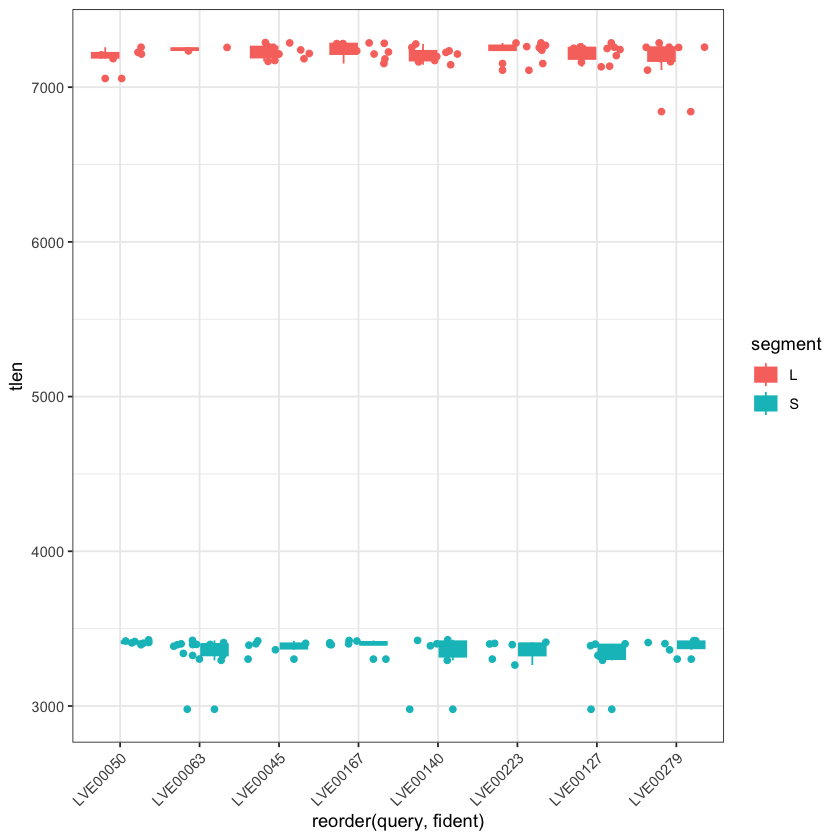

In [21]:
# Checking the observed diversity of references. (arrange with increasing mean fident)
ggplot(selected_references, aes(y = tlen, x = reorder(query, fident), fill = segment, color=segment)) +
  geom_boxplot() +
  geom_jitter() +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [22]:
fident_window_to_digits <- function(x) {
  rng <- str_match(as.character(x), "\\[?(0?\\.\\d+),\\s*(1|0?\\.\\d+)\\]")
  lo <- as.numeric(rng[, 2])
  hi <- as.numeric(rng[, 3])
  sprintf("%02d%02d", round(lo * 100), round(hi * 100))
}

system("mkdir -p data-preparation/selected-references")

write_tsv(selected_references, "data-preparation/selected-references/selected_references.tsv")

out_dir <- "data-preparation/selected-references"

collapse <- selected_references%>%
    group_by(query, fident_window)%>%
    summarise(
      targets_regex = paste(target,collapse = " " ),
      segment = paste(segment, collapse =" ")
    )%>%
    ungroup()

`summarise()` has grouped output by 'query'. You can override using the
`.groups` argument.


In [23]:
head(collapse)

query,fident_window,targets_regex,segment
<chr>,<fct>,<chr>,<chr>
LVE00045,"[0.64,0.66]",MT199231.1,L
LVE00045,"(0.66,0.68]",MT199235.1,L
LVE00045,"(0.68,0.7]",OR041677.1,S
LVE00045,"(0.72,0.74]",OR041684.1,S
LVE00045,"(0.74,0.76]",MK117836.1,L
LVE00045,"(0.76,0.78]",ON569374.1,L


In [24]:
system("mkdir -p data-preparation/selected-references")

apply(collapse, 1, function(x) {
    sample <- x[1]
    fident_window <- x[2]
    targets_regex <- x[3]
    fident_digits <- fident_window_to_digits(fident_window)
    outname <- gsub(" ", "-", targets_regex)
    regex <- gsub(" ",")|(", targets_regex)
    out_file <- glue("{out_dir}/{fident_digits}_{outname}.fasta")
    command <- glue("cat data-preparation/ncbi-virus-fasta/sequences_*_LASV.fasta | seqkit grep -r -p '({regex})' > {out_file}")
    system(command)
})

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [38] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [75] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[112] 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [26]:
unique(collapse$query)

[1] "LVE00045" "LVE00050" "LVE00063" "LVE00127" "LVE00140" "LVE00167" "LVE00223"
[8] "LVE00279"

In [34]:
RVDB <- data.frame(
        sample = unique(collapse$query),
        sequence = rep("/lustre1/project/stg_00132/databases/RVDB/U-RVDBv29.0.fasta", length(unique(collapse$query))))%>%
    mutate(
        id= glue("{sample}-RVDB")
    )

collapse%>%
    mutate(
        id= glue("{query}-{fident_window_to_digits(fident_window)}"),
        sample = query,
        sequence = glue("{out_dir}/{fident_window_to_digits(fident_window)}_{gsub(' ', '-', targets_regex)}.fasta")
    )%>%
    select(id, sample, sequence, segment)%>%
    bind_rows(., RVDB)%>%
    arrange(sample)%>%
    write_csv( "reference_pools.csv")